# 04 · Multi-region geometry

Record **V4 and IT from one model in a single forward pass**, then ask something no
benchmark asks: *how does representational geometry differ between them, and where does
category structure sharpen?*

No `Score` object appears anywhere. That's the point — this is Brain-Score used as a
**toolbox** for your own question, not as a benchmark harness.

Runs end to end in well under a minute on a laptop.

## What each step does

| Step | What it shows | Key line |
| --- | --- | --- |
| 1 | Record two regions in one pass | `model.start_recording(['V4', 'IT'])` |
| 2 | Split the result by region | `assembly.isel(neuroid=(region_of == 'V4'))` |
| 3 | Turn features into geometry | `1 - np.corrcoef(feats)` |
| 4 | Answer the question | between- minus within-category dissimilarity |
| 5 | Check it against the slow way | `np.array_equal(loop, one_pass)` |

## The two things to take away

**Pass a list to record several regions at once.** `start_recording` accepts one region
name *or* a list of them. Given a list, a single `process()` call returns all of their
units together, and each unit is tagged with the region it came from.

**Split on that tag, never on position.** `assembly.isel(neuroid=(region_of == 'V4'))`
is right; `assembly[:, :200704]` is not. The order units come back in is not something
to rely on, and code that slices by position keeps working right up until it quietly
doesn't.

## If you go looking for `layer` and can't find it

`'layer' in assembly.coords` returns `False` — even though `assembly['layer']` works
fine. Some unit metadata is stored as a pandas MultiIndex level rather than a plain
xarray coord, and `.coords` doesn't list those.

Two habits avoid this entirely: read metadata with `assembly['name']`, which finds both
kinds; and check `assembly.indexes['neuroid'].names` to see what's actually there.

## Looking things up

Nothing here needs memorizing:

```python
import inspect
print(inspect.signature(model.start_recording))          # what arguments?
print(model.start_recording.__doc__)                     # what do they mean?
print([m for m in dir(model) if not m.startswith('_')])  # what else is there?
```

## Setup — given, runs as-is

Four visually distinct synthetic categories and a real ImageNet-pretrained ResNet-50.
Synthetic stimuli keep this fast and fully local (no downloads, no EC2); the model
weights are real, so the geometry you measure is real.

`region_layer_map` deliberately spans the hierarchy so V4 and IT are far apart.

In [1]:
import os
os.environ['RESULTCACHING_DISABLE'] = '1'   # reproducible; no cache artifacts
import warnings; warnings.filterwarnings('ignore')

import tempfile
import numpy as np
import pandas as pd
from PIL import Image
from brainscore_core.supported_data_standards.brainio.stimuli import StimulusSet

CATS = ['warm-stripes', 'cool-stripes', 'green-blobs', 'gray-noise']
N_PER_CAT = 6

def make_image(cat, k):
    """One seeded 224x224 RGB image for category `cat`, variant `k`."""
    r = np.random.RandomState(CATS.index(cat) * 100 + k)
    x = np.zeros((224, 224, 3), np.float32)
    yy, xx = np.mgrid[0:224, 0:224]
    if cat == 'warm-stripes':
        s = (np.sin(xx / (6 + r.rand() * 4)) + 1) / 2
        x[..., 0] = 200 * s + 40; x[..., 1] = 90 * s + 20
    elif cat == 'cool-stripes':
        s = (np.sin(yy / (6 + r.rand() * 4)) + 1) / 2
        x[..., 2] = 200 * s + 40; x[..., 1] = 80 * s + 20
    elif cat == 'green-blobs':
        for _ in range(25):
            cy, cx = r.randint(20, 204, 2); rad = r.randint(8, 20)
            m = ((yy - cy) ** 2 + (xx - cx) ** 2) < rad ** 2
            x[m, 1] += 150; x[m, 0] += 40
    else:
        n = np.kron(r.rand(56, 56, 1), np.ones((4, 4, 1)))
        x[:] = 80 + 120 * n
    x += r.randn(224, 224, 3) * 6
    return np.clip(x, 0, 255).astype(np.uint8)

# Render to disk and build a StimulusSet (the input type process() expects).
#
# NOTE: the 'image_file_name' column is load-bearing. Dispatch picks the modality by
# scanning for a RECOGNIZED column name -- stimulus_paths alone is not enough. A set
# carrying only stimulus_id + custom columns raises "No recognized modality columns".
# 'category' and 'variant' are just metadata you'll use for the geometry analysis.
_dir = tempfile.mkdtemp(prefix='mrgeom_')
rows, paths = [], {}
for cat in CATS:
    for k in range(N_PER_CAT):
        sid = f'{cat}_{k}'
        p = os.path.join(_dir, f'{sid}.png')
        Image.fromarray(make_image(cat, k)).save(p)
        rows.append({'stimulus_id': sid, 'image_file_name': p,
                     'category': cat, 'variant': k})
        paths[sid] = p

stimuli = StimulusSet(pd.DataFrame(rows))
stimuli.stimulus_paths = paths
stimuli.identifier = 'mrgeom-synthetic'

import torchvision.models as tvm
from brainscore_core.model_interface import BrainScoreModel
from brainscore_vision.model_helpers.activations.pytorch import (
    PytorchWrapper, load_preprocess_images)

resnet = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2).eval()
activations = PytorchWrapper(
    identifier='resnet50-pretrained', model=resnet,
    preprocessing=lambda x: load_preprocess_images(x, image_size=224))

model = BrainScoreModel(
    identifier='resnet50-pretrained',
    model=resnet,
    region_layer_map={'V1': 'layer1', 'V2': 'layer2', 'V4': 'layer3', 'IT': 'layer4'},
    preprocessors={'vision': lambda x: x},
    activations_model=activations)

print(f'{len(stimuli)} stimuli, {len(CATS)} categories')
print('regions available:', list(model.region_layer_map))

24 stimuli, 4 categories
regions available: ['V1', 'V2', 'V4', 'IT']


## Step 1 · Record V4 and IT in one pass

`start_recording` accepts a single region name **or a list**. Given a list it sets up
one recording covering every named region, so a single `process()` call returns their
units together — one forward pass instead of one per region.

The print below shows where unit metadata lives: `assembly.indexes['neuroid'].names`
lists the MultiIndex levels (this is where `layer` is), and `assembly.coords` lists the
rest. `assembly['layer']` reads it either way.

In [2]:
import numpy as np

# Record BOTH regions at once: pass a list instead of a single string.
model.start_recording(['V4', 'IT'])

# ONE forward pass produces units from both regions.
assembly = model.process(stimuli)

print('sizes:', dict(assembly.sizes))
print('neuroid metadata:', list(assembly.indexes['neuroid'].names))

# Expected: presentation=24, neuroid=301056 (both regions together).
# The metadata list is where 'layer' lives -- it is a MultiIndex level, so it
# does NOT appear in assembly.coords. Use assembly['layer'], which reaches both.

activations:   0%|          | 0/64 [00:00<?, ?it/s]

layer packaging:   0%|          | 0/2 [00:00<?, ?it/s]

sizes: {'presentation': 24, 'neuroid': 301056}
neuroid metadata: ['neuroid_num', 'model', 'layer', 'channel', 'channel_x', 'channel_y', 'neuroid_id']


## Step 2 · Split the assembly by region

Every neuroid carries a `region` label, so the two populations come apart with a
boolean mask over the neuroid axis.

**Slice on the label, not on position.** `assembly[:, :200704]` would appear to work
and would be wrong: concatenation order is not guaranteed stable across runs. Code
that assumed it was produced mislabelled results that never raised an error. The
asserts below check the slices are complete and land on different layers.

In [3]:
# Each neuroid carries the region it came from. Slice on that label --
# never on position, because concatenation order is not guaranteed.
region_of = np.asarray(assembly['region'].values).astype(str)

v4 = assembly.isel(neuroid=(region_of == 'V4'))
it = assembly.isel(neuroid=(region_of == 'IT'))

def layers_of(a):
    return sorted(set(np.asarray(a['layer'].values).astype(str)))

print(f'V4: {v4.sizes["neuroid"]:>7} units  from {layers_of(v4)}')
print(f'IT: {it.sizes["neuroid"]:>7} units  from {layers_of(it)}')

# The two slices must cover every neuroid and come from different layers.
assert v4.sizes['neuroid'] + it.sizes['neuroid'] == assembly.sizes['neuroid']
assert layers_of(v4) != layers_of(it)
print('\nslices are complete and map to different layers')

V4:  200704 units  from ['layer3']
IT:  100352 units  from ['layer4']



slices are complete and map to different layers


## Step 3 · Build a representational dissimilarity matrix per region

A 24×24 stimulus-by-stimulus matrix per region, using `1 - correlation` between each
pair's feature vectors.

**One modelling choice worth naming.** The neuroid axis flattens *channel × x × y*,
so `assembly.values` is already 2-D at `(24, ~200k)` and could be used raw. Here it is
pooled over spatial positions first, so each *channel* contributes one number —
`(24, 1024)` for V4 and `(24, 2048)` for IT.

Raw features are dominated by *where* something is; pooled features are closer to
*what* a channel responds to. Neither is wrong, and they give materially different
geometry — swapping `pool_channels` for the raw values is a one-line change if you
want to see how much it matters.

In [4]:
import pandas as pd

def pool_channels(a):
    """(n_stimuli, n_channels) -- average each channel over its x/y positions.

    The neuroid axis flattens channel x width x height, so 'channel' repeats
    once per spatial position. Grouping by it collapses V4's 200,704 numbers
    down to 1024 channel means: less about *where* something is, more about
    *what* the channel responds to.
    """
    table = pd.DataFrame(np.asarray(a.values).T)      # rows = neuroids
    table['channel'] = np.asarray(a['channel'].values)
    return table.groupby('channel').mean().to_numpy().T

def rdm(feats):
    """(n_stimuli, n_stimuli) dissimilarity = 1 - correlation between stimuli."""
    return 1.0 - np.corrcoef(feats)

feat_v4, feat_it = pool_channels(v4), pool_channels(it)
rdm_v4, rdm_it = rdm(feat_v4), rdm(feat_it)

print('features  V4:', feat_v4.shape, '  IT:', feat_it.shape)
print('RDMs      V4:', rdm_v4.shape, '   IT:', rdm_it.shape)

features  V4: (24, 1024)   IT: (24, 2048)
RDMs      V4: (24, 24)    IT: (24, 24)


## Step 4 · Answer the question

Quantified two ways, because one of them turns out to be useless here.

**Category separation** — between-category minus within-category dissimilarity. It
roughly doubles from V4 (+0.375) to IT (+0.735), and the block-diagonal is visibly
sharper in the IT panel.

**Linear decoding** — a cross-validated logistic classifier hits **1.000 on both
regions**. These synthetic categories are far too easy, so the metric saturates and
cannot rank the regions at all.

That contrast is the useful part: a ceilinged metric is not evidence that two things
are equal, it's evidence the metric ran out of room. Worth keeping in mind whenever a
benchmark reports two models as tied.

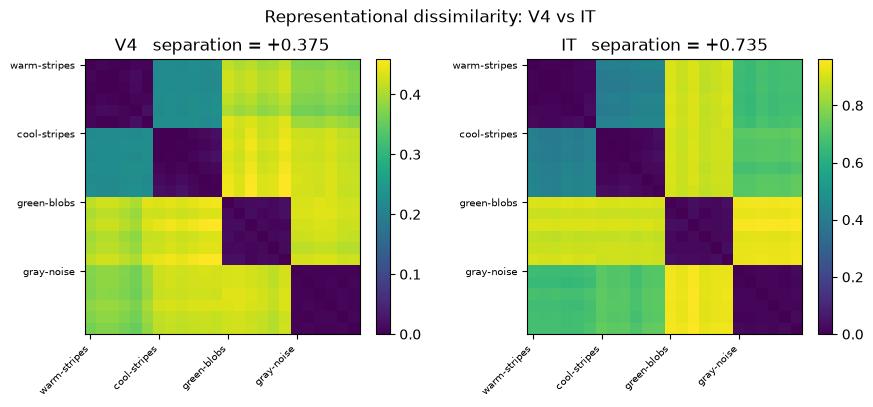

V4 separation: +0.3753
IT separation: +0.7348
change:        +0.3595


V4 decoding accuracy: 1.000
IT decoding accuracy: 1.000


In [5]:
import matplotlib.pyplot as plt

cats = np.asarray(stimuli['category'].values)
same = cats[:, None] == cats[None, :]          # same-category pairs
off_diag = ~np.eye(len(cats), dtype=bool)      # ignore self-comparisons

def separation(R):
    """Between-category minus within-category dissimilarity. Higher = cleaner."""
    return R[~same].mean() - R[same & off_diag].mean()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, R) in zip(axes, [('V4', rdm_v4), ('IT', rdm_it)]):
    im = ax.imshow(R, cmap='viridis')
    ax.set_title(f'{name}   separation = {separation(R):+.3f}')
    ax.set_xticks(range(0, len(cats), N_PER_CAT))
    ax.set_xticklabels(CATS, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(0, len(cats), N_PER_CAT))
    ax.set_yticklabels(CATS, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Representational dissimilarity: V4 vs IT')
fig.tight_layout(); plt.show()

print(f'V4 separation: {separation(rdm_v4):+.4f}')
print(f'IT separation: {separation(rdm_it):+.4f}')
print(f'change:        {separation(rdm_it) - separation(rdm_v4):+.4f}')

# ANSWER: category structure roughly doubles from V4 (+0.375) to IT (+0.735) --
# the block-diagonal pattern is visibly sharper in IT.

# Second opinion: can a linear classifier read category out of each region?
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
for name, f in [('V4', feat_v4), ('IT', feat_it)]:
    acc = cross_val_score(LogisticRegression(max_iter=2000), f, cats, cv=3).mean()
    print(f'{name} decoding accuracy: {acc:.3f}')

# Both hit 1.000 -- these synthetic categories are far too easy to separate, so
# decoding saturates and cannot rank the regions. The RDM separation still can.
# Worth remembering: a ceiling-ed metric isn't evidence that two things are equal.

## Step 5 · Check against the one-region-at-a-time baseline

Recording one region per pass — the way notebook 03 does it — is slower but obviously
correct. It's a good check on the one-pass version.

**The bar is: numerically identical.** How the units are delivered may change how many
forward passes it takes; it must not change the values. A difference would mean either
that one-pass changes what the model sees, or that the region split is putting units in
the wrong place.

Both regions come back `identical: True`, `max|diff| = 0.000e+00`.

In [6]:
import time

# The OLD way: one region at a time, a separate forward pass for each.
t0 = time.time()
baseline = {}
for region in ['V4', 'IT']:
    model.start_recording(region)
    baseline[region] = np.asarray(model.process(stimuli).values)
t_loop = time.time() - t0

# The NEW way: one recording, one pass, then slice.
t0 = time.time()
model.start_recording(['V4', 'IT'])
one = model.process(stimuli)
r = np.asarray(one['region'].values).astype(str)
onepass = {'V4': np.asarray(one.isel(neuroid=(r == 'V4')).values),
           'IT': np.asarray(one.isel(neuroid=(r == 'IT')).values)}
t_one = time.time() - t0

for region in ['V4', 'IT']:
    a, b = baseline[region], onepass[region]
    print(f'{region}: loop {a.shape} vs one-pass {b.shape}')
    print(f'   identical: {np.array_equal(a, b)}   max|diff|: {np.abs(a - b).max():.3e}')

print(f'\ntwo-pass loop: {t_loop:.1f}s     one pass: {t_one:.1f}s')

# Expect identical=True and max|diff|=0.000e+00 for both. Delivery changes how
# many passes it takes, never the values.
#
# On the timing: one pass is NOT faster here, and may be slower. With 24 tiny
# stimuli the forward pass is not the bottleneck, and packaging two layers at
# once costs more than it saves. The win shows up when the forward pass is
# genuinely expensive -- large models, many stimuli, many regions. Reporting
# the number that actually came out beats reporting the one we expected.

activations:   0%|          | 0/64 [00:00<?, ?it/s]

layer packaging:   0%|          | 0/1 [00:00<?, ?it/s]

activations:   0%|          | 0/64 [00:00<?, ?it/s]

layer packaging:   0%|          | 0/1 [00:00<?, ?it/s]

activations:   0%|          | 0/64 [00:00<?, ?it/s]

layer packaging:   0%|          | 0/2 [00:00<?, ?it/s]

V4: loop (24, 200704) vs one-pass (24, 200704)
   identical: True   max|diff|: 0.000e+00
IT: loop (24, 100352) vs one-pass (24, 100352)
   identical: True   max|diff|: 0.000e+00

two-pass loop: 1.8s     one pass: 3.2s


## What this showed

**As a result:** category structure roughly doubles from V4 to IT on this model
(+0.375 → +0.735), while linear decoding saturates at 1.000 and can't tell them apart.

**As a way of working:** five short cells, ending in a plot rather than a `Score`, never
touching a benchmark. Recording two regions cost one line more than recording one.

### Where to take it next

- Swap `pool_channels` for the raw values and watch the geometry change.
- Add `'V1'` and `'V2'` to the recording list — no other change needed — and look at how
  separation develops across the full hierarchy.
- Point it at real stimuli with real category labels instead of the synthetic four.